### Import libraries

In [43]:
# Import the relevant libraries for this exercise session
import time
import numpy as np
from scipy.io import loadmat
from scipy.optimize import minimize
from matplotlib import pyplot as plt
from matplotlib.cm import get_cmap
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared

import GPy

# To supress some of the GPy warnings later on.
import warnings
warnings.filterwarnings("ignore")

### Read data

In [44]:
out = np.load('../gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.npz')
th_data = out['th'] #th[0],th[1],th[2],th[3],...
u_data = out['u'] #u[0],u[1],u[2],u[3],...

### Plot data

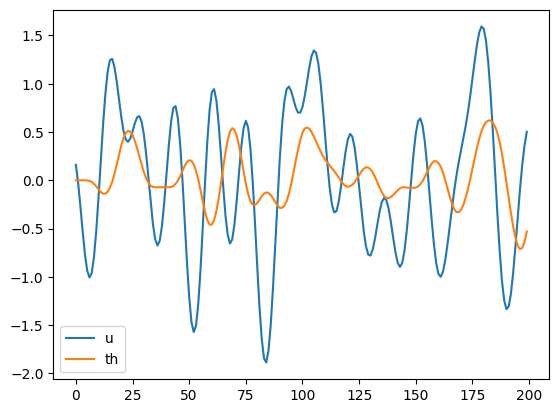

In [45]:
num_samples_to_show = 200
plt.plot(u_data[:num_samples_to_show])
plt.plot(th_data[:num_samples_to_show])
plt.legend(['u','th']);

### Construct train and validation data for prediction

In [46]:
na, nb = 2,2
split = 0.75 #75% training and 25% validation split

def create_IO_data(u,y,na,nb) -> tuple:
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        X.append(np.concatenate([u[k-nb:k],y[k-na:k]]))
        Y.append(y[k])
    return np.array(X), np.array(Y)

def create_split_datasets(u,y,na,nb,split) -> tuple:
    split_index = int(len(u)*split) 
    Xtrain, Ytrain = create_IO_data(u[:split_index],y[:split_index], na, nb) 
    Xval,   Yval   = create_IO_data(u[split_index:],y[split_index:], na, nb)
    return Xtrain, Ytrain, Xval, Yval


Xtrain, Ytrain, Xval, Yval = create_split_datasets(u_data, th_data, na, nb, split)

print('Xtrain.shape',Xtrain.shape)
print('Ytrain.shape',Ytrain.shape)
print('Xval.shape',Xval.shape)

Xtrain.shape (26248, 4)
Ytrain.shape (26248,)
Xval.shape (8748, 4)


In [47]:
def simulation_IO_model(f, ulist, ylist, skip=50):

    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    for u in ulist[skip:]:
        x = np.concatenate([upast,ypast],axis=0)
        y_pred_mu = f(x)
        Y.append(y_pred_mu)
        upast.append(u)
        upast.pop(0)
        ypast.append(y_pred_mu)
        ypast.pop(0)
    return np.array(Y)

### Construct validation data for simulation

In [48]:
split = 0.8
split_index = int(len(u_data)*split) 
u_train_for_sim = u_data[:split_index]
th_train_for_sim = th_data[:split_index]
u_val_for_sim = u_data[split_index:]
th_val_for_sim = th_data[split_index:]

# GP model using SK Learn

In [61]:
def fit_SKlearn_GP(Xtrain, Ytrain, RBF_length_scale=0.1, WhiteKernel_noise_level=0.01):
    ker = (RBF(length_scale=RBF_length_scale) * ExpSineSquared(length_scale=4.0)) + WhiteKernel(noise_level=WhiteKernel_noise_level)
    reg = GaussianProcessRegressor(ker, n_restarts_optimizer=10)
    reg.fit(Xtrain,Ytrain)
    return reg
    
def SK_GP_prediction(reg, Xval, Yval, type='Prediction on the validation set'):
    N_show = 500
    # Prediction on the training set
    Y_pred, Y_pred_std = reg.predict(Xval,return_std=True) 
    plt.figure(figsize=(12,5)) 
    plt.plot(Yval[:N_show], label='measured')
    plt.plot(Y_pred[:N_show], label='predicted')
    plt.title("Prediction on the " + type + " set")
    # plt.errorbar(np.arange(len(Xval)), (Y_pred), yerr=2*Y_pred_std,fmt='.r') 


    plt.fill_between(
        np.arange(len(Y_pred[:N_show])),
        Y_pred[:N_show] - 2*Y_pred_std[:N_show],
        Y_pred[:N_show] + 2*Y_pred_std[:N_show],
        color='blue',
        alpha=0.3,
        label="95% confidence"
    )
    plt.grid(); plt.xlabel('sample'); plt.ylabel('th'); plt.legend()
    plt.show() 

    print(type + ' prediction errors:')
    print('RMS:', np.mean((Y_pred-Yval)**2)**0.5,'radians')
    print('RMS:', np.mean((Y_pred-Yval)**2)**0.5/(2*np.pi)*360,'degrees')
    print('Validation NRMS:', np.mean((Y_pred-Yval)**2)**0.5/Yval.std()*100,'%')

def SK_GP_simulation(reg, u_train, th_train, na, nb, type='training'):
    N_show = 500
    skip = max(na,nb)
    th_train_sim = simulation_IO_model(lambda x: reg.predict(x[None,:])[0], u_train, th_train, skip=skip)

    plt.figure(figsize=(12,5))
    plt.title('Simulation on the ' + type + ' set')
    plt.plot(th_train[:N_show], label='measured')
    plt.plot(th_train_sim[:N_show], label='simulated')
    plt.grid()
    plt.xlabel('sample')
    plt.ylabel('th')
    plt.legend()
    plt.show() 


    print(type + ' simulation errors:')
    print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5,'radians')
    print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5/(2*np.pi)*360,'degrees')
    print('NRMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5/th_train.std()*100,'%')




Train on the first 1000 samples

In [50]:
reg = fit_SKlearn_GP(Xtrain[:1000], Ytrain[:1000])

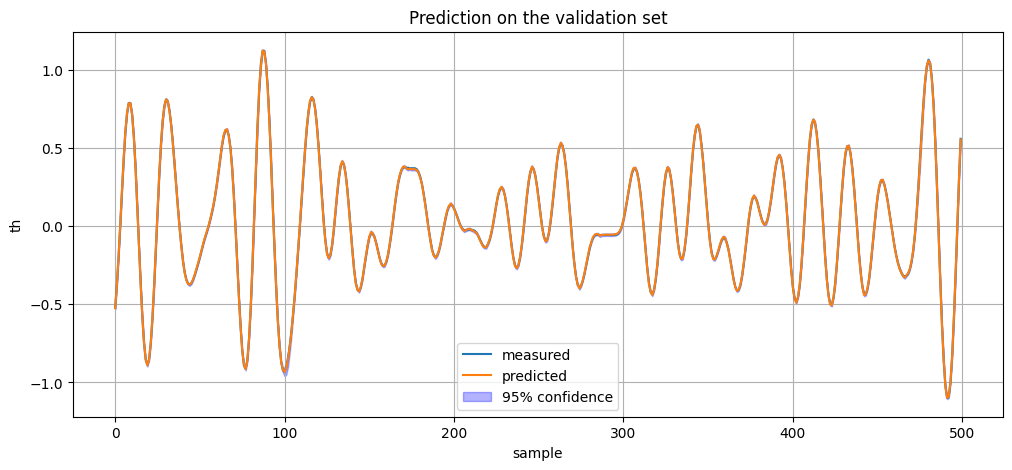

validation prediction errors:
RMS: 0.007669203941322707 radians
RMS: 0.43941301806288774 degrees
Validation NRMS: 1.5160964555393552 %


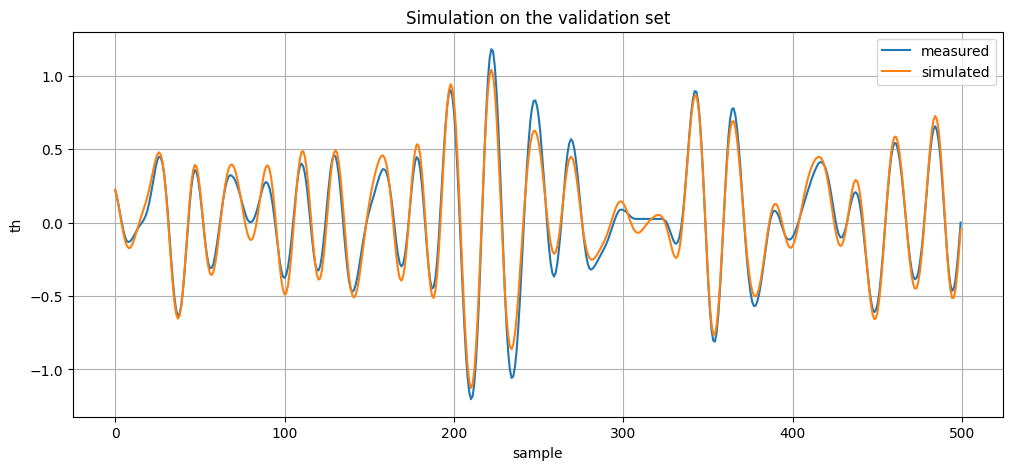

validation simulation errors:
RMS: 0.20925941353760738 radians
RMS: 11.989681219087666 degrees
NRMS: 40.476902754429176 %


In [62]:
SK_GP_prediction(reg, Xval, Yval, type='validation')
SK_GP_simulation(reg, u_val_for_sim, th_val_for_sim, na, nb, type='validation')

# GP model using GPy 

In [52]:
def GP_prediction(model, X, Y, type='validation'):
    N_show = 500

    Y_pred_mu, Y_pred_var = model.predict(X)
    Y_pred_mu = Y_pred_mu.squeeze()
    Y_pred_std = np.sqrt(Y_pred_var.squeeze())
    Y = Y.squeeze()

    plt.figure(figsize=(12,5))

    plt.plot(Y_pred_mu[:N_show], label="GP mean")
    plt.plot(Y[:N_show], label="True output")

    plt.fill_between(
        np.arange(len(Y_pred_mu[:N_show])),
        Y_pred_mu[:N_show] - 2*Y_pred_std[:N_show],
        Y_pred_mu[:N_show] + 2*Y_pred_std[:N_show],
        color='blue',
        alpha=0.3,
        label="95% confidence"
    )

    plt.legend()
    plt.xlabel("Time step")
    plt.ylabel("Output")
    plt.title("NARX GP prediction with uncertainty on the " + type + " set")
    plt.show()

    print('RMS:', np.mean((Y_pred_mu-Y)**2)**0.5,'radians')
    print('RMS:', np.mean((Y_pred_mu-Y)**2)**0.5/(2*np.pi)*360,'degrees')
    # print(f'{type.capitalize()} NRMS= {np.mean((Y_pred_mu-Y)**2)**0.5/np.std(Y)}') 

def GP_simulation(model, u, th, type='validation'):
    N_show = 500
    skip = max(na,nb)
    th_sim = simulation_IO_model(lambda x: model.predict(x[None,:])[0][0][0], u, th, skip=skip)

    plt.figure(figsize=(12,5))
    plt.title('Simulation on the ' + type + ' set')
    plt.plot(th[:N_show], label='measured')
    plt.plot(th_sim[:N_show], label='simulated')
    plt.grid()
    plt.xlabel('sample')
    plt.ylabel('th')
    plt.legend()
    plt.show() 


    print(type + ' simulation errors:')
    print('RMS:', np.mean((th_sim[skip:]-th[skip:])**2)**0.5,'radians')
    print('RMS:', np.mean((th_sim[skip:]-th[skip:])**2)**0.5/(2*np.pi)*360,'degrees')
    # print('NRMS:', np.mean((th_sim[skip:]-th[skip:])**2)**0.5/th.std()*100,'%')

## Full GP fit (on 2000 datapoints)

In [53]:
# kernel = GPy.kern.RBF(input_dim=Xtrain.shape[1], lengthscale=0.1) + GPy.kern.White(input_dim=Xtrain.shape[1], variance=0.01)
k_rbf = GPy.kern.RBF(input_dim=Xtrain.shape[1], lengthscale=0.1, ARD=True)
k_white = GPy.kern.White(input_dim=Xtrain.shape[1], variance=0.01)
th_dim = np.arange(Xtrain.shape[1])[-na:]  # The last 'na' dimensions correspond to the output history, I think those are periodic
print('th_dim', th_dim)
k_periodic = GPy.kern.StdPeriodic(input_dim=len(th_dim), active_dims=th_dim, lengthscale=0.1, period=4.2)
kernel = (k_rbf * k_periodic) + k_white


Full_GP_model = GPy.models.GPRegression(Xtrain[:2000],Ytrain[:2000].reshape(-1,1), kernel=kernel)
print(Full_GP_model)
Full_GP_model.optimize('bfgs', messages=True)
# Full_GP_model.plot()
print (Full_GP_model)

th_dim [2 3]

Name : GP regression
Objective : 2536.3453732271623
Number of Parameters : 10
Number of Optimization Parameters : 10
Updates : True
Parameters:
  GP_regression.                    |  value  |  constraints  |  priors
  sum.mul.rbf.variance              |    1.0  |      +ve      |        
  sum.mul.rbf.lengthscale           |   (4,)  |      +ve      |        
  sum.mul.std_periodic.variance     |    1.0  |      +ve      |        
  sum.mul.std_periodic.period       |    4.2  |      +ve      |        
  sum.mul.std_periodic.lengthscale  |    0.1  |      +ve      |        
  sum.white.variance                |   0.01  |      +ve      |        
  Gaussian_noise.variance           |    1.0  |      +ve      |        
Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    14s50  0005  -2.889417e+03   8.399651e+05 
    58s60  0021  -7.958735e+03   1.349227e+02 
 02m41s33  0058  -7.990223e+03   1.048016e+00 
 05m19s47  0104  -7.990241e+03   

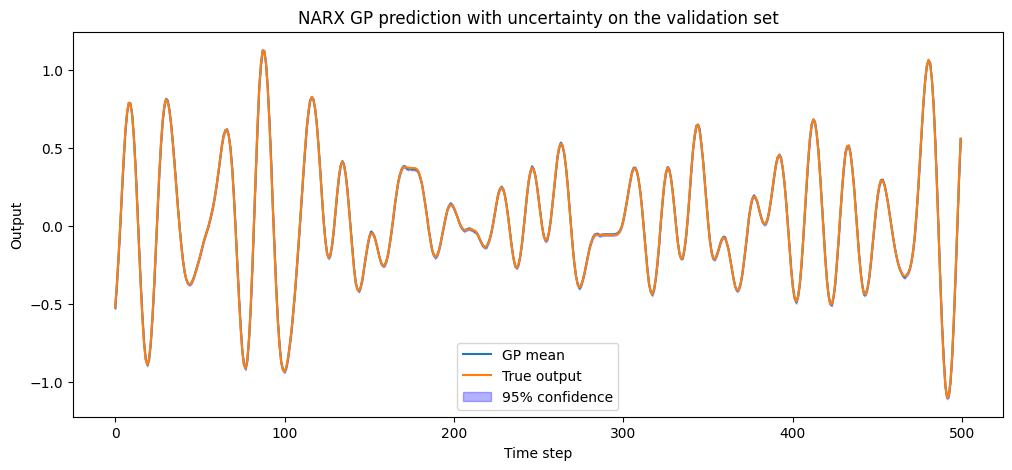

RMS: 0.004829424091934732 radians
RMS: 0.2767056179466602 degrees


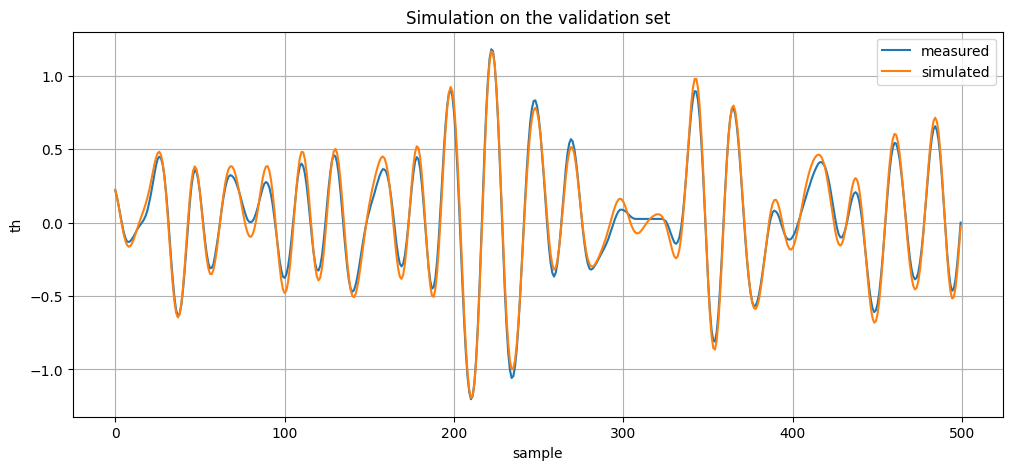

validation simulation errors:
RMS: 0.1836736968088626 radians
RMS: 10.523727634713325 degrees


In [54]:
GP_prediction(Full_GP_model, Xval, Yval, type='validation')
GP_simulation(Full_GP_model, u_val_for_sim, th_val_for_sim, type='validation')

# Sparse GP fitting

In [55]:
M = 500  # number of inducing points
k_rbf = GPy.kern.RBF(input_dim=Xtrain.shape[1], lengthscale=0.1, ARD=True)
k_white = GPy.kern.White(input_dim=Xtrain.shape[1], variance=0.01)
th_dim = np.arange(Xtrain.shape[1])[-na:]  # The last 'na' dimensions correspond to the output history, I think those are periodic
k_periodic = GPy.kern.StdPeriodic(input_dim=len(th_dim), active_dims=th_dim, lengthscale=0.1, period=4.2)
kernel = (k_rbf * k_periodic) + k_white
Sparse_GP_model = GPy.models.SparseGPRegression(Xtrain,Ytrain.reshape(-1,1),num_inducing=M, kernel=kernel)
print(Sparse_GP_model)
Sparse_GP_model.optimize('bfgs',messages=True)
# Sparse_GP_model.plot() does not work because the input space is na+nb which is always more than 2
print(Sparse_GP_model.log_likelihood())
print(Sparse_GP_model)
# np.save('sparse_gp_pendulum_500M_na4_nb4.npy', Sparse_GP_model.param_array)


Name : sparse_gp
Objective : 37389.35046819941
Number of Parameters : 2010
Number of Optimization Parameters : 2010
Updates : True
Parameters:
  sparse_gp.                        |     value  |  constraints  |  priors
  inducing_inputs                   |  (500, 4)  |               |        
  sum.mul.rbf.variance              |       1.0  |      +ve      |        
  sum.mul.rbf.lengthscale           |      (4,)  |      +ve      |        
  sum.mul.std_periodic.variance     |       1.0  |      +ve      |        
  sum.mul.std_periodic.period       |       4.2  |      +ve      |        
  sum.mul.std_periodic.lengthscale  |       0.1  |      +ve      |        
  sum.white.variance                |      0.01  |      +ve      |        
  Gaussian_noise.variance           |       1.0  |      +ve      |        
Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    50s45  0002   3.026688e+04   4.182279e+07 
 03m24s10  0012  -8.679869e+04   6.672850e

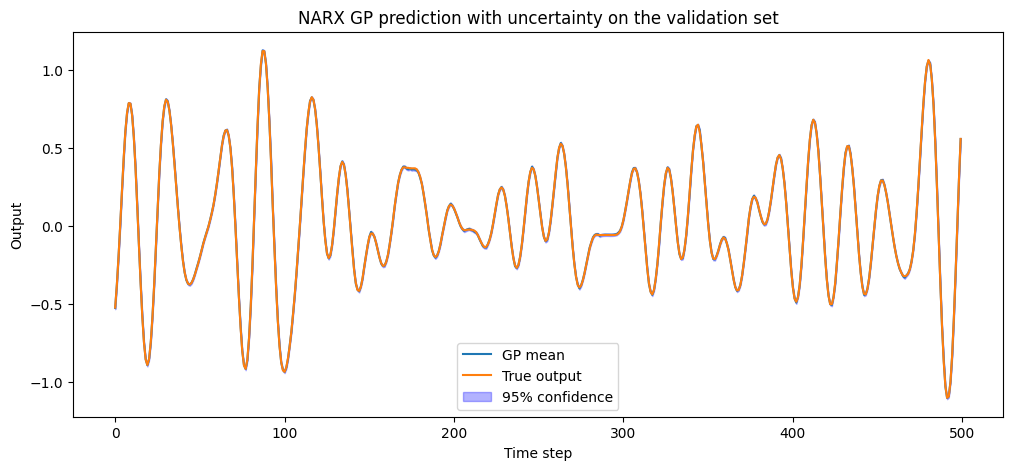

RMS: 0.003917404368962627 radians
RMS: 0.22445073698766807 degrees


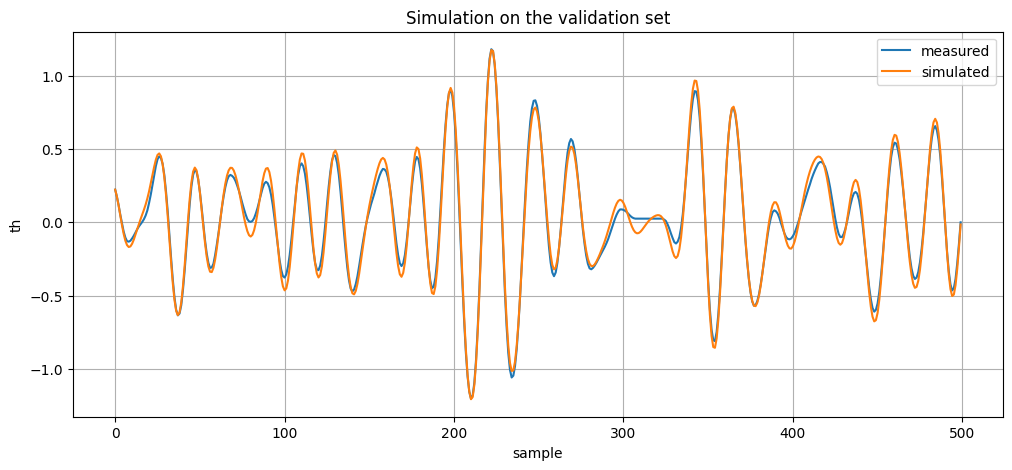

validation simulation errors:
RMS: 0.08280820226116671 radians
RMS: 4.744560498630533 degrees


In [56]:
GP_prediction(Sparse_GP_model, Xval, Yval, type='validation')
GP_simulation(Sparse_GP_model, u_val_for_sim, th_val_for_sim, type='validation')

## Hyper-parameter optimization
na, nb

(length scale and other kernel parameters are optimized by the model.optimize())

In [57]:
# M_list = [500, 1000]  # number of inducing points
# na_list = [2,3,5]
# nb_list = [2,3,5]
# with open('results.txt', 'w') as f:
#     f.write('M, na, nb, RMS_pred_degrees, RMS_sim_degrees\n')

# for na in na_list:
#     for nb in nb_list:
#         for M in M_list:
#             print(f'--- [M={M}, na={na}, nb={nb}] ---')
#             Xtrain, Ytrain, Xval, Yval = create_split_datasets(u_data, th_data, na, nb, split)
#             kernel = GPy.kern.RBF(input_dim=Xtrain.shape[1], lengthscale=0.1) + GPy.kern.White(input_dim=Xtrain.shape[1], variance=0.01)
#             model = GPy.models.SparseGPRegression(Xtrain,Ytrain.reshape(-1,1),num_inducing=M, kernel=kernel)
#             start_time = time.time()
#             model.optimize('bfgs')
#             end_time = time.time()
#             print(model)
#             print(f'log_likelihood={model.log_likelihood()}, opt time={end_time - start_time}')


#             Y_pred_mu, Y_pred_var = model.predict(Xval)
#             Y_pred_mu = Y_pred_mu.squeeze()
#             Y_pred_std = np.sqrt(Y_pred_var.squeeze())
#             Yval = Yval.squeeze()

#             RMS_radians = np.mean((Y_pred_mu-Yval)**2)**0.5
#             RMS_degrees = RMS_radians/(2*np.pi)*360
#             NRMS = RMS_radians/Yval.std()*100

#             Y_sim = simulation_IO_model(lambda x: model.predict(x[None,:])[0][0][0], u_val_for_sim, th_val_for_sim, skip=max(na,nb))
#             RMS_sim_radians = np.mean((Y_sim[max(na,nb):]-th_val_for_sim[max(na,nb):])**2)**0.5
#             RMS_sim_degrees = RMS_sim_radians/(2*np.pi)*360
#             NRMS_sim = RMS_sim_radians/th_val_for_sim.std()*100

#             print(f'Prediction RMS: {RMS_radians:0.4f} radians, {RMS_degrees:0.2f} degrees, NRMS: {NRMS}%')
#             print(f'Simulation RMS: {RMS_sim_radians:0.4f} radians, {RMS_sim_degrees:0.2f} degrees, NRMS: {NRMS_sim}%\n')

#             with open('results.txt', 'a') as f:
#                 f.write(f'M={M}, na={na}, nb={nb}, RMS_pred_degrees={RMS_degrees:0.2f}, RMS_sim_degrees={RMS_sim_degrees:0.2f}\n')
            

## Predict unseen test data

The actual output is unknown.

In [58]:
data = np.load('../gym-unbalanced-disk/disc-benchmark-files/hidden-test-prediction-submission-file.npz')
upast_test = data['upast'] #N by u[k-15],u[k-14],...,u[k-1]
thpast_test = data['thpast'] #N by y[k-15],y[k-14],...,y[k-1]

#only select the ones that are used in the example
Xtest_submission = np.concatenate([upast_test[:,15-nb:], thpast_test[:,15-na:]],axis=1)

Ypredict = reg.predict(Xtest_submission)
assert len(Ypredict)==len(upast_test), 'number of samples changed!!'

## Save submission file

In [59]:
np.savez('../gym-unbalanced-disk/submission-files/hidden-test-prediction-GP-NARX-submission-file.npz', upast=upast_test, thpast=thpast_test, thnow=Ypredict)

## Simulate unseen test data

In [60]:
data = np.load('../gym-unbalanced-disk/disc-benchmark-files/hidden-test-simulation-submission-file.npz')
u_test = data['u']
th_test = data['th'] #only the first 50 values are filled the rest are zeros

skip = 50
th_test_sim = simulation_IO_model(lambda x: reg.predict(x[None,:])[0], u_test, th_test, skip=skip)

assert len(th_test_sim)==len(th_test)
np.savez('../gym-unbalanced-disk/submission-files/hidden-test-simulation-example-submission-file.npz', th=th_test_sim, u=u_test)